In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
n_points = 120
dates = pd.date_range(start='2020-01-01', periods=n_points, freq='M')

# Create time series with trend, seasonality, and noise
trend = np.linspace(0, 50, n_points)
seasonal = 10 * np.sin(2 * np.pi * np.arange(n_points) / 12)  # Yearly seasonality
noise = np.random.normal(0, 2, n_points)

values = 100 + seasonal + noise

df = pd.DataFrame({
    'date': dates,
    'value': values
})
df.set_index('date', inplace=True)
df

,value
date,
2020-01-31,100.993428
2020-02-29,104.723471
2020-03-31,109.955631
2020-04-30,113.046060
2020-05-31,108.191947
...,...
2029-08-31,95.603095
2029-09-30,91.270322
2029-10-31,87.662644


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
def train_model(data, forecast_steps=12):
  forecast_horizon = forecast_steps
  window_size = len(data)
  monthly_dates = []
  for i in range(1, 13):
      next_date = data.index[-1] + relativedelta(months=i)
      monthly_dates.append(next_date)
  actuals = []
  for i in range(len(data) - forecast_steps):
    actuals.append(np.exp(np.sum(data.iloc[i: i + 12, 0])) * 100 - 100)
  actuals = pd.DataFrame(actuals, index = data.index[-len(actuals):])
  forecast = []
  for i in range(len(data), len(data) + 1):
    forecasts_aux = []
    trivial_aux = []
    for m in range(1, forecast_horizon + 1):
      forc = []
      var = []
      for k in range(1, 5):
          p_max = 0.01
          df_aux = data.iloc[i - window_size // k:i, 0].copy()
          df_aux = df_aux.rolling(m).mean()
          while np.sum(np.abs(df_aux - np.mean(df_aux)) / np.std(df_aux) > 3) > 0:
              df_aux[(df_aux - np.mean(df_aux)) / np.std(df_aux) > 3] = np.mean(df_aux) + 1.9 * np.std(df_aux)
              df_aux[(df_aux - np.mean(df_aux)) / np.std(df_aux) < -3] = np.mean(df_aux) - 1.9 * np.std(df_aux)
          train = pd.DataFrame(df_aux)
          if m <= 9:
              lags = [m, m + 1, m + 2, 12]
          elif m == 10:
              lags = [m, m + 1, 12]
          elif m == 11:
              lags = [m, 12]
          elif m == 12:
              lags = [12]
          X_p = [1]
          for j in lags:
              train['y_lag' + str(j)] = df_aux.shift(j)
              X_p.append(list(df_aux)[-j + m - 1])
          X_p = pd.DataFrame(np.array(X_p).reshape(1, -1), columns = train.columns)
          spisok = []
          matrix = train.corr()
          cor_max = 0.7
          target = 'value'
          for k in matrix.columns:
              for p in matrix.index:
                  if k != p and k != target and p != target:
                      if np.abs(matrix[k][p]) > cor_max:
                          if np.abs(matrix[target][p]) > np.abs(matrix[target][k]):
                              spisok.append(k)
                          else:
                              spisok.append(p)
          spisok = set(spisok)
          train = train.drop(spisok, axis = 1)

          X_p = X_p.drop(spisok, axis = 1)
          X_p = list(X_p.loc[0])

          train = train.dropna()
          model = sm.OLS(train['value'], sm.add_constant(train.drop('value', axis = 1))).fit()
          X = train.drop('value', axis = 1)
          while np.max(model.pvalues[1:]) > p_max:
              X = X.drop(X.columns[np.argmax(model.pvalues[1:])], axis = 1)
              X_p.pop(np.argmax(model.pvalues[1:]) + 1)
              model = sm.OLS(train['value'], sm.add_constant(X)).fit()

          forc.append(model.predict(X_p)[0])
          var.append(model.mse_resid)
      forecasts_aux.append(np.sum(np.array(forc) / np.array(var)) / np.sum(1 / np.array(var)))
      trivial_aux.append(np.median(data[i-12:i]))
      if m == 1:
        w = [1, 0, 0]
      elif m == 2:
        w = [0.7, 0.2, 0.1]
      elif m == 3:
        w = [0.5, 0.2, 0.3]
      elif m == 4:
        w = [0.4, 0.3, 0.3]
      elif m == 5:
        w = [0.4, 0.4, 0.2]
      elif m == 6:
        w = [0.4, 0.4, 0.2]
      elif m == 7:
        w = [0.4, 0.4, 0.2]
      elif m == 8:
        w = [0.4, 0.4, 0.2]
      elif m == 9:
        w = [0.4, 0.4, 0.2]
      elif m == 10:
        w = [0.4, 0.4, 0.2]
      elif m == 11:
        w = [0.4, 0.4, 0.2]
      elif m == 12:
        w = [0.3, 0.5, 0.2]
      forecast.append(np.exp(np.sum(data[i - (12 - m): i]) + m * (forecasts_aux[m - 1] * w[0] + trivial_aux[m - 1] * w[1] + 4 / 1200 * w[2])) * 100 - 100)
  forecast = pd.DataFrame(forecast, index = monthly_dates)

  return forecast, actuals

data = np.log((df / 100).cumprod()).diff(1) # преобразовываем входные данные по ИПЦ

forc, act = train_model(data, forecast_steps=12)
forc

,value
2030-01-31,0.004514
2030-02-28,0.017769
2030-03-31,-4.537020
2030-04-30,-9.128793
2030-05-31,-14.281281
2030-06-30,-19.912410
2030-07-31,-17.391598
2030-08-31,-19.089250
2030-09-30,-10.411004
2030-10-31,-4.904716


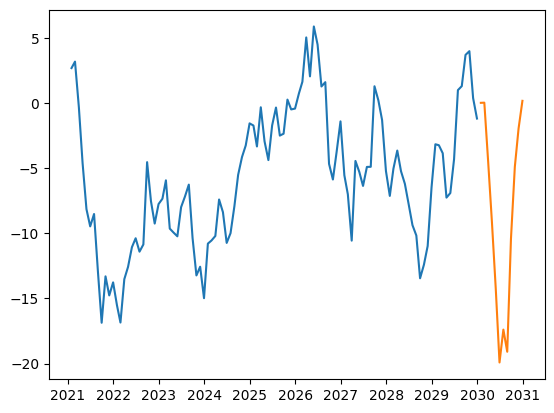

In [3]:
plt.plot(act)
plt.plot(forc)